#**IMPORTING FILES**

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Crimes_Cleaned.csv to Crimes_Cleaned.csv


In [2]:
csv_file = list(uploaded.keys())[0]

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap
import seaborn as sns

In [4]:
csv_file = list(uploaded.keys())[0]
df_raw = pd.read_csv(csv_file)

print("Original dataset:", df_raw.shape)

Original dataset: (41780, 26)


#**DATA CLEANING**

In [5]:
df_clean = df_raw.copy()
df_clean.shape[0]

41780

In [6]:
# Removing leading and trailing spaces
df_clean['Description'] = df_clean['Description'].str.strip()

# Removing multi spaces with single space
df_clean['Description'] = df_clean['Description'].str.replace(r'\s+', ' ', regex=True)

df_clean['Arrest'] = df_clean['Arrest'].astype(bool)
df_clean['Domestic'] = df_clean['Domestic'].astype(bool)

In [7]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')
df_clean['month'] = df_clean['Date'].dt.month
df_clean['month_name'] = df_clean['Date'].dt.month_name()
df_clean['day'] = df_clean['Date'].dt.day_name()
df_clean['hour'] = df_clean['Date'].dt.hour
df_clean['Year'] = df_clean['Date'].dt.year

midnight_hour_mask = (df_clean['Date'].dt.hour == 0) & \
                (df_clean['Date'].dt.minute == 0) & \
                (df_clean['Date'].dt.second == 0)
df_clean.loc[midnight_hour_mask, 'hour'] = pd.NA

In [8]:
df_clean = df_clean.dropna()
df_clean = df_clean.reset_index(drop=True)
print(f"Rows after dropping missing values: {df_clean.shape[0]}")

Rows after dropping missing values: 39367


In [9]:
df_clean['Description'] = df_clean['Description'].astype(str).str.strip().str.upper()

#**SELECTING A PARTICULAR CRIME**

In [10]:
df_clean.Description.value_counts()

,count
Description,
TELEPHONE THREAT,19528
CREDIT CARD FRAUD,12125
FALSE / STOLEN / ALTERED TRP,5417
COMPUTER FRAUD,1620
VIOLATION GPS MONITORING DEVICE,450
CYBERSTALKING,227


In [11]:
CRIME_DESCRIPTION = "TELEPHONE THREAT"
# "CREDIT CARD FRAUD"
# "FALSE / STOLEN / ALTERED TRP"
# "COMPUTER FRAUD"
# "VIOLATION GPS MONITORING DEVICE"
# "CYBERSTALKING"

In [12]:
print(f"Crime selected: {CRIME_DESCRIPTION}")
print("Records after filtering:", df_clean.shape)

Crime selected: TELEPHONE THREAT
Records after filtering: (39367, 26)


In [13]:
single_crime_df = df_clean[df_clean['Description'].str.contains(CRIME_DESCRIPTION, na=False)]
single_crime_df.Description.value_counts()

,count
Description,
TELEPHONE THREAT,19528


#**HEATMAPS AND BAR CHART**

##**OVERALL HEATMAP OF A PARTICULAR CRIME**

In [14]:
map_overall_crime = folium.Map(location=[41.88, -87.63], zoom_start=12)
HeatMap(single_crime_df[['Latitude','Longitude']].dropna().values.tolist(), radius=10, blur=8).add_to(map_overall_crime)

print(f"Overall Heatmap for {CRIME_DESCRIPTION}:")
map_overall_crime

Overall Heatmap for TELEPHONE THREAT:


##**AVERAGE HOURWISE CHART OF A PARTICULAR CRIME**

In [15]:
overall_hour_counts = single_crime_df.groupby('hour').size().reset_index(name='crime_count')
overall_hour_counts = overall_hour_counts.sort_values(by='crime_count', ascending=False)

print(f"Top 10 hours with the highest {CRIME_DESCRIPTION} crime counts:")
display(overall_hour_counts.head(10))

Top 10 hours with the highest TELEPHONE THREAT crime counts:


,hour,crime_count
12,12.0,1509
9,9.0,1282
10,10.0,1232
11,11.0,1167
14,14.0,1162
13,13.0,1160
15,15.0,1155
16,16.0,1113
17,17.0,1099
18,18.0,1057


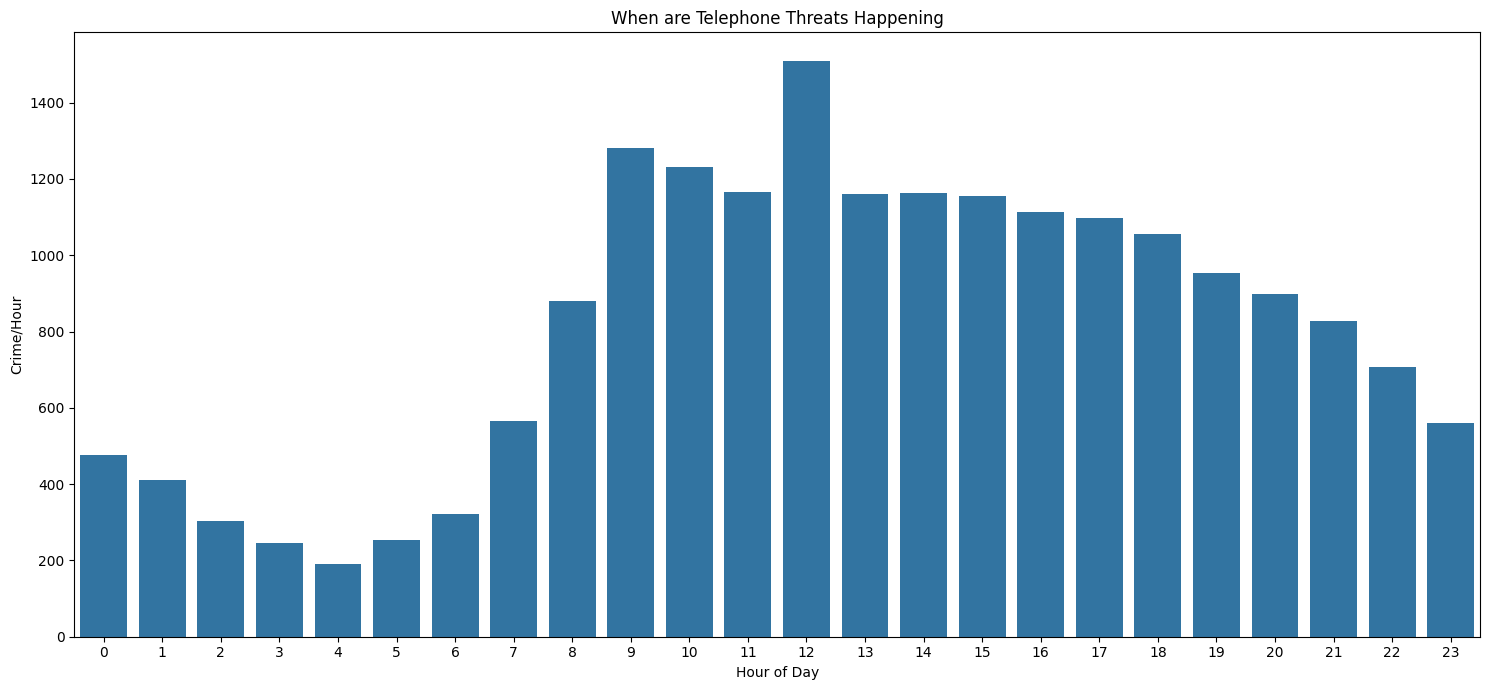

In [16]:
all_hours = pd.DataFrame({'hour': range(24)})
overall_hour_counts_full = pd.merge(all_hours, overall_hour_counts, on='hour', how='left').fillna(0)

plt.figure(figsize=(15, 7))
sns.barplot(x='hour', y='crime_count', data=overall_hour_counts_full)
plt.title(f'When are Telephone Threats Happening')
plt.xlabel('Hour of Day')
plt.ylabel('Crime/Hour')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

###**AVERAGE HIGHEST HOUR HEATMAP**

In [17]:
highest_crime_hour = overall_hour_counts.iloc[0]['hour']
highest_hour_df = single_crime_df[single_crime_df['hour'] == highest_crime_hour]

map_highest_hour_crime = folium.Map(location=[41.88, -87.63], zoom_start=12)
HeatMap(highest_hour_df[['Latitude','Longitude']].dropna().values.tolist(), radius=5, blur=3).add_to(map_highest_hour_crime)

print(f"Heatmap for {CRIME_DESCRIPTION} during the highest crime hour ({int(highest_crime_hour)}):")
map_highest_hour_crime

Heatmap for TELEPHONE THREAT during the highest crime hour (12):
